# Analysis for odd responses sqisign

In [22]:
from pathlib import Path
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
import math

In [2]:
p = 62

# Use the newest merged file for this p.
files = sorted(Path('.').glob(f'data/{p}-birandom-merged-*.csv.zip'))
if not files:
    raise FileNotFoundError(f'No merged CSV found for p={p}')
data_file = files[-1]
data_file

PosixPath('data/62-birandom-merged-20260714-084637.csv.zip')

In [3]:
columns = (
    ['I1', 'I2', 'I3', 'I4']
    + ['OL2', 'OL3', 'OL4']
    + ['OR2', 'OR3', 'OR4']
    + [f'inner{i}{j}' for i in range(1, 5) for j in range(1, 5)]
)

df = pd.read_csv(data_file, compression='zip', comment='#', header=None, names=columns)
df

,I1,I2,I3,I4,OL2,OL3,OL4,OR2,OR3,OR4,...,inner23,inner24,inner31,inner32,inner33,inner34,inner41,inner42,inner43,inner44
0,0.199057,0.373286,1.125247,1.166691,0.041085,1.155270,1.432343,0.153889,0.627164,0.680539,...,1,1,0,1,1,1,0,1,1,0
1,0.357934,0.502966,0.558076,1.063522,0.263841,0.273651,0.882299,0.230327,0.426679,0.640375,...,0,1,1,0,1,1,0,1,1,0
2,0.215919,0.410024,0.603909,1.335379,0.382591,0.438924,0.549756,0.264093,0.399542,0.667413,...,0,0,1,0,0,1,0,0,1,0
3,0.186652,0.299044,1.033956,1.202712,0.228714,0.357403,0.812369,0.030545,0.301301,6.885653,...,0,1,0,0,1,1,1,1,1,0
4,0.548765,0.557894,0.654248,0.680699,0.280264,0.462858,0.602370,0.173849,0.440133,0.902464,...,0,1,0,0,1,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1389595,0.303508,0.488673,0.721278,0.893016,0.063247,0.766835,1.331061,0.108911,0.222514,2.655366,...,1,0,1,1,1,1,0,0,1,1
1389596,0.234448,0.337540,0.387869,2.526348,0.255071,0.522148,0.569731,0.116665,0.500064,1.186384,...,0,1,0,0,0,1,1,1,1,0
1389597,0.297053,0.469958,0.759035,0.904049,0.227549,0.309063,1.016116,0.170942,0.531672,0.744135,...,0,1,1,0,0,1,0,1,1,0
1389598,0.495633,0.512171,0.517708,0.730855,0.274642,0.553622,0.565361,0.060011,1.024492,1.025603,...,0,0,0,0,0,1,0,0,1,1


In [4]:
total_record = len(df)
total_record

1389600

We can easily check that it never happens that all 3 minima and their combinations are all even

In [86]:
print((df['inner11']*df['inner22']*df['inner12']*df['inner23']*df['inner13']*df['inner33']).sum()/total_record)

0.0


In [10]:
df[['I1', 'I2', 'I3', 'I4']].corr()

,I1,I2,I3,I4
I1,1.000000,0.060854,-0.485474,-0.298137
I2,0.060854,1.000000,-0.005128,-0.267849
I3,-0.485474,-0.005128,1.000000,0.022982
I4,-0.298137,-0.267849,0.022982,1.000000


In [12]:
inner_cols = ['inner11', 'inner12', 'inner13', 'inner14',
   'inner21', 'inner22', 'inner23', 'inner24',
   'inner31', 'inner32', 'inner33', 'inner34',
   'inner41', 'inner42', 'inner43', 'inner44']
df["n_nonzero_inner"] = (df[inner_cols] != 0).sum(axis=1)
distribution = df["n_nonzero_inner"].value_counts().sort_index()
print(distribution/total_record)

n_nonzero_inner
4     0.016742
5     0.056767
6     0.085376
7     0.171456
8     0.171593
9     0.209637
10    0.114324
11    0.057617
12    0.078465
13    0.038025
Name: count, dtype: float64


In [13]:
inner_cols = ['inner11', 'inner12', 'inner13', 'inner22', 'inner23', 'inner33']
df["n_nonzero_inner"] = (df[inner_cols] != 0).sum(axis=1)
distribution = df["n_nonzero_inner"].value_counts().sort_index()
print(distribution/total_record)

n_nonzero_inner
1    0.028520
2    0.257324
3    0.313793
4    0.285548
5    0.114816
Name: count, dtype: float64


In [14]:
df[inner_cols].corr()

,inner11,inner12,inner13,inner22,inner23,inner33
inner11,1.000000,-0.068884,-0.072063,-0.071568,0.003984,-0.070739
inner12,-0.068884,1.000000,-0.071216,-0.069224,-0.071178,0.004204
inner13,-0.072063,-0.071216,1.000000,0.005267,-0.071263,-0.071064
inner22,-0.071568,-0.069224,0.005267,1.000000,-0.071145,-0.071429
inner23,0.003984,-0.071178,-0.071263,-0.071145,1.000000,-0.072227
inner33,-0.070739,0.004204,-0.071064,-0.071429,-0.072227,1.000000


<Axes: >

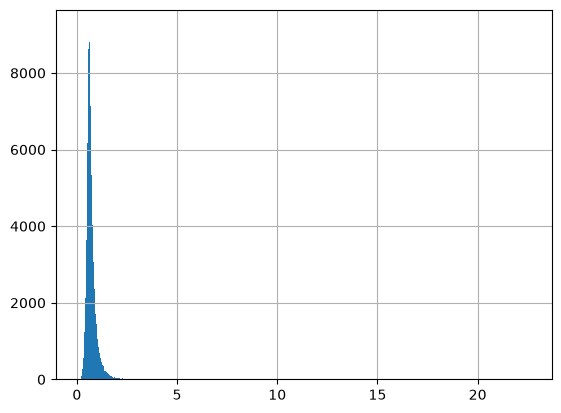

In [15]:
(df['I3']).hist(bins=10000)

<Axes: >

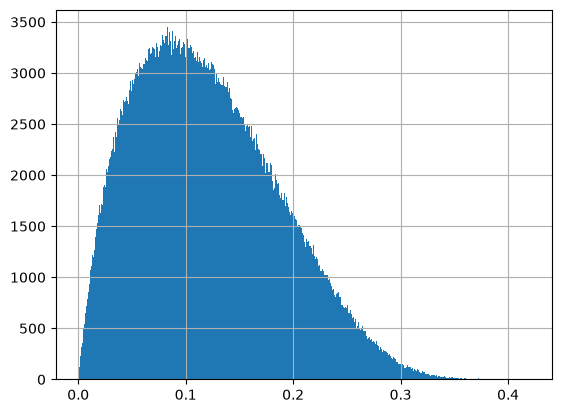

In [16]:
(df['I1']*df['I2']).hist(bins=1000)

In [17]:
df['I12'] = df['I1'] * df['I2']

In [18]:
df[['I12','OR2', 'OR3', 'OR4']].corr()

,I12,OR2,OR3,OR4
I12,1.000000,-0.000548,-0.000405,-0.000744
OR2,-0.000548,1.000000,-0.295505,-0.107100
OR3,-0.000405,-0.295505,1.000000,-0.019635
OR4,-0.000744,-0.107100,-0.019635,1.000000


In [19]:
dfmin = df[['I1', 'I2', 'I3', 'I4']]
corr = dfmin.corr(method="spearman", numeric_only=True)
corr

,I1,I2,I3,I4
I1,1.000000,0.156712,-0.500062,-0.746171
I2,0.156712,1.000000,0.062978,-0.579379
I3,-0.500062,0.062978,1.000000,0.047506
I4,-0.746171,-0.579379,0.047506,1.000000


In [20]:
df["I3-I1"] = df["I3"] - df["I1"]

## 3rd minima estimates

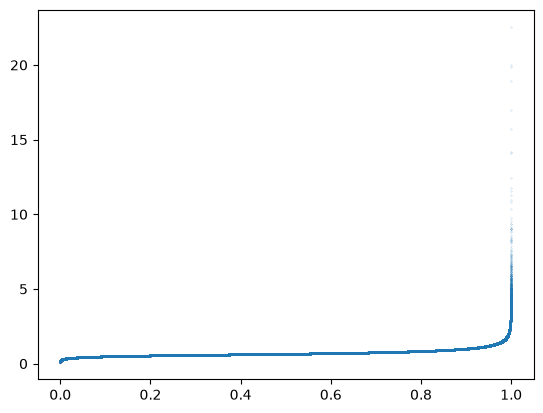

In [323]:
d = (df["I3"]).to_numpy() 

n = len(d)
x = np.sort(d)
plt.scatter(np.arange(n)/n, x, s = 0.01)

# x values from 0 to max(d)
x_vals = np.linspace(0, d.max(), 500)

# y = number of samples bigger than x
counts = np.array([(d > x).sum() for x in x_vals]) / n

# optional: fit only the tail, e.g. fit_quantile=0.7
threshold = np.quantile(d, 1 - 0.99)





In [91]:

# x values from 0 to max(d)
lin_span = 1000
x_vals = np.linspace(0, d.max(), lin_span)

# y = number of samples bigger than x
counts = np.array([(d > x).sum() for x in x_vals]) / n

# optional: fit only the tail, e.g. fit_quantile=0.7
threshold = np.quantile(d, 1 - 0.5)

mask = (x_vals > 0) & (counts > 0) & (x_vals >= threshold) #& (x_vals < 20)


0.5462428670506676 10.388692570998094
Considering only 435/1000 values


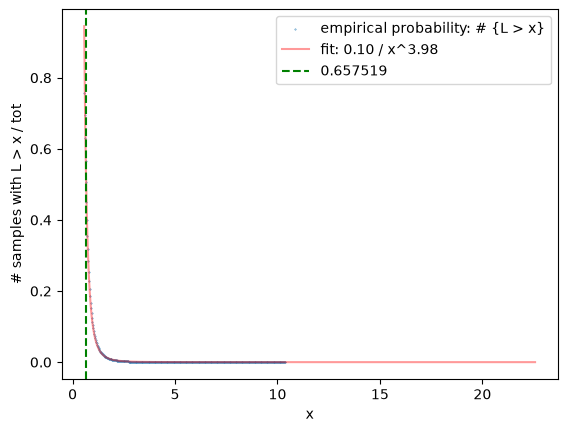

In [92]:
threshold_low = np.quantile(d, 0.2)
threshold_up = np.quantile(d, 1 - 0.00001)
print(threshold_low, threshold_up)
mask = (x_vals > 0) & (counts > 0) & (x_vals >= threshold_low) & (x_vals <= threshold_up)

print(f'Considering only {sum(mask)}/{len(mask)} values')
log_x = np.log(x_vals[mask])
log_y = np.log(counts[mask])

slope, intercept = np.polyfit(log_x, log_y, 1)

a_hat = -slope
C_hat = np.exp(intercept)

fit_y = np.zeros_like(x_vals, dtype=float)

mask_pos = x_vals > 0
fit_y[mask_pos] = C_hat * x_vals[mask_pos] ** (-a_hat)

mask_plot = mask_pos & (fit_y < 1)

plt.scatter(x_vals[mask], counts[mask],
            label="empirical probability: # {L > x}",
            s=0.1)

plt.plot(x_vals[mask_plot], fit_y[mask_plot],
         label=f"fit: {C_hat:.2f} / x^{a_hat:.2f}",
         color="red", alpha = 0.4)

plt.xlabel("x")
plt.ylabel("# samples with L > x / tot")
plt.axvline(x = threshold, color = 'green', linestyle="--", label=f'{threshold:f}')

plt.legend()
plt.show()

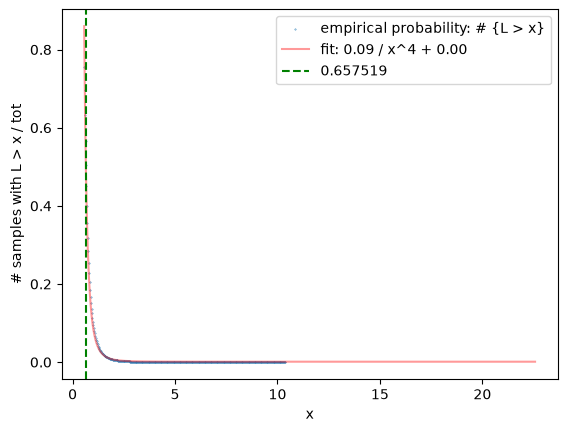

In [93]:
a = 4
xv = x_vals[mask] ** -a
lyv = counts[mask]

slope, intercept = np.polyfit(xv, lyv, 1)

fit_y = np.zeros_like(x_vals, dtype=float)

mask_pos = x_vals > 0
fit_y[mask_pos] = slope * x_vals[mask_pos] ** (-a) + intercept

mask_plot = mask_pos & (fit_y < 1)

plt.scatter(x_vals[mask], counts[mask],
            label="empirical probability: # {L > x}",
            s=0.1)

plt.plot(x_vals[mask_plot], fit_y[mask_plot],
         label=f"fit: {slope:.2f} / x^{a} + {intercept:.2f}",
         color="red", alpha = 0.4)

plt.xlabel("x")
plt.ylabel("# samples with L > x / tot")
plt.axvline(x = threshold, color = 'green', linestyle="--", label=f'{threshold:f}')

plt.legend()
plt.show()

In [94]:
from scipy.stats import norm
import math

d = np.sort(df["I3"].dropna().to_numpy())
n = len(d)

alpha0 = 4

rows = []
perc_span = np.linspace(0.0002, 0.005, 100)

for perc in perc_span:
    k = math.ceil(perc*n)
    u = d[-k-1]
    tail = d[-k:]
    gamma_hat = np.mean(np.log(tail / u))
    alpha_hat = 1 / gamma_hat
    
    se = alpha_hat / math.sqrt(k)
    
    # Test H0: alpha = 4 using the Hill asymptotic normal approximation
    se0 = alpha0 / math.sqrt(k)
    z = (alpha_hat - alpha0) / se0
    p_value = 2 * (1 - norm.cdf(abs(z)))
    
    rows.append({
        "k": k,
        "perc": perc,
        "threshold": u,
        "alpha_hat": alpha_hat,
        "ci_low": alpha_hat - 1.96 * se,
        "ci_high": alpha_hat + 1.96 * se,
        "z_alpha_eq_alpha0": z,
        "p_value_alpha_eq_alpha0": p_value,
        "C_hat_alpha0": (k / n) * u**4,
    })

out = pd.DataFrame(rows)
out

,k,perc,threshold,alpha_hat,ci_low,ci_high,z_alpha_eq_alpha0,p_value_alpha_eq_alpha0,C_hat_alpha0
0,278,0.000200,4.712196,3.998697,3.528638,4.468756,-0.005432,0.995666,0.098639
1,346,0.000248,4.503107,4.135067,3.699354,4.570780,0.628099,0.529939,0.102385
2,413,0.000297,4.325210,4.175677,3.772953,4.578401,0.892545,0.372101,0.104013
3,481,0.000345,4.157778,4.127668,3.758786,4.496551,0.699996,0.483930,0.103443
4,548,0.000394,3.984480,3.955914,3.624697,4.287131,-0.258005,0.796403,0.099398
...,...,...,...,...,...,...,...,...,...
95,6679,0.004806,2.132430,3.972634,3.877359,4.067909,-0.559128,0.576074,0.099385
96,6746,0.004855,2.127753,3.977631,3.882711,4.072551,-0.459311,0.646011,0.099504
97,6814,0.004903,2.121288,3.969465,3.875214,4.063716,-0.630143,0.528601,0.099291
98,6881,0.004952,2.115596,3.965967,3.872258,4.059675,-0.705782,0.480324,0.099196


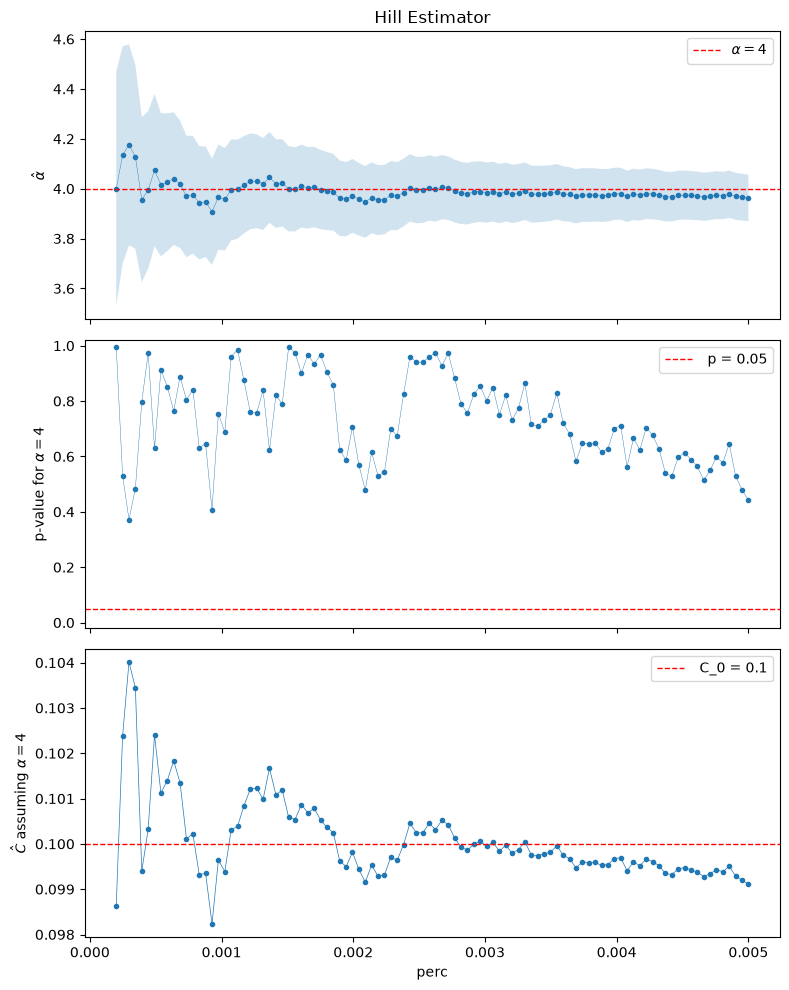

In [95]:
title = 'Hill Estimator'
fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

ax = axes[0]
ax.plot(out["perc"], out["alpha_hat"], marker=".", linewidth=0.3)
ax.fill_between(out["perc"], out["ci_low"], out["ci_high"], alpha=0.2)
ax.axhline(alpha0, color="red", linestyle="--", linewidth=1, label=fr"$\alpha={alpha0}$")
ax.set_ylabel(r"$\hat\alpha$")
ax.set_title(title or "Hill tail diagnostics")
ax.legend()

ax = axes[1]
ax.plot(out["perc"], out["p_value_alpha_eq_alpha0"], marker=".", linewidth=0.3)
p = 0.05
ax.axhline(p, color="red", linestyle="--", linewidth=1, label=f"{ p = }")
ax.set_ylabel(fr"p-value for $\alpha={alpha0}$")
ax.set_ylim(-0.02, 1.02)
ax.legend()

ax = axes[2]
ax.plot(out["perc"], out["C_hat_alpha0"], marker=".", linewidth=0.5)
C_0 = 0.1
ax.axhline(C_0, color="red", linestyle="--", linewidth=1, label=f"{ C_0 = }")
ax.set_ylabel(fr"$\hat C$ assuming $\alpha={alpha0}$")
ax.set_xlabel("perc")
ax.legend()

plt.tight_layout()
plt.show()


## 1st and 2nd minima product estimate

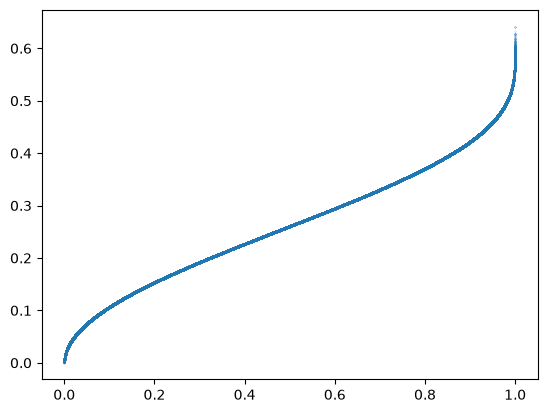

In [96]:
# d = (df["I1"]*df["I2"]).to_numpy() 
d = (df["I1"]).to_numpy() 
n = len(d)
x = np.sort(d)
plt.scatter(np.arange(n)/n, x, s = 0.01)

In [97]:
# x values from 0 to max(d)
x_vals = np.linspace(0, d.max(), 10000)

# y = number of samples bigger than x
counts = np.array([(d < x).sum() for x in x_vals]) / n

# optional: only consider vectors shorter than c * p 
# seems, that c = 0.01 start to give results
threshold = 0.3

# the reason for this sieve is that we expect that for shorter vectors the heuristic will better hold
# and we only care about the short case, corresponding to the long tail for lambda_3
mask = (x_vals > 0) & (counts > 0) & (x_vals <= threshold)

# TODO: understand the number theory behind this

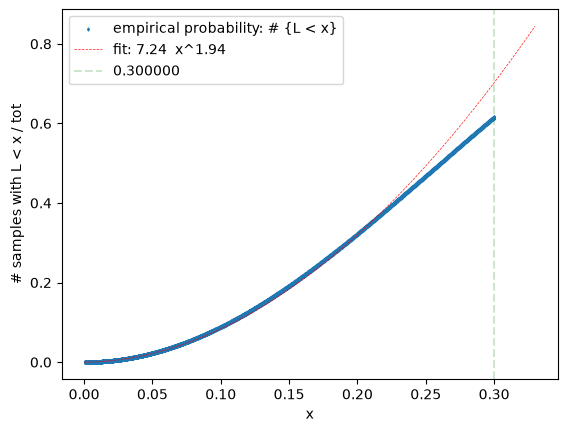

Considering 5143 points


In [98]:

log_x = np.log(x_vals[mask])
log_y = np.log(counts[mask])

slope, intercept = np.polyfit(log_x, log_y, 1)

a_hat = slope
C_hat = np.exp(intercept)

fit_y = np.zeros_like(x_vals, dtype=float)

mask_pos = x_vals > 0
fit_y[mask_pos] = C_hat * x_vals[mask_pos] ** (a_hat)

mask_plot = mask_pos & (fit_y < 1) & (x_vals <= threshold*1.1)

plt.scatter(x_vals[mask], counts[mask],
            label="empirical probability: # {L < x}",
            s=2, marker = 'd')

plt.plot(x_vals[mask_plot], fit_y[mask_plot],
         label=f"fit: {C_hat:.2f}  x^{a_hat:.2f}",
         color="red", alpha=0.9, linestyle="--", linewidth=0.5)

plt.xlabel("x")
plt.ylabel("# samples with L < x / tot")
plt.axvline(x = threshold, color = 'green', linestyle="--", label=f'{threshold:f}', alpha=0.2)

plt.legend()
plt.show()

print(f'Considering {sum([ 1 for m in mask_plot if m])} points')

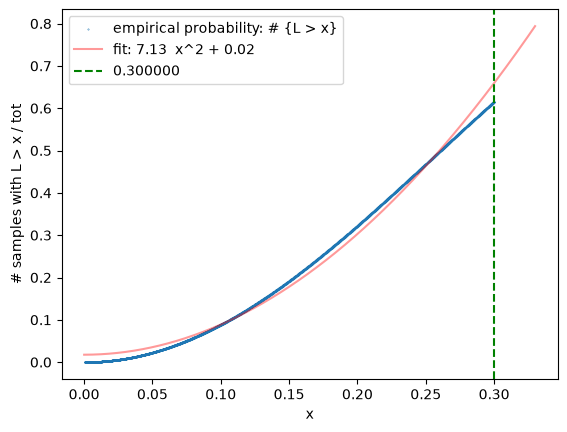

In [99]:
a = 2
xv = x_vals[mask] ** a
lyv = counts[mask]

slope, intercept = np.polyfit(xv, lyv, 1)

fit_y = np.zeros_like(x_vals, dtype=float)

mask_pos = x_vals > 0
fit_y[mask_pos] = slope * x_vals[mask_pos] ** (a) + intercept

mask_plot = mask_pos & (fit_y < 1) & (x_vals <= threshold*1.1)

plt.scatter(x_vals[mask], counts[mask],
            label="empirical probability: # {L > x}",
            s=0.1)

plt.plot(x_vals[mask_plot], fit_y[mask_plot],
         label=f"fit: {slope:.2f}  x^{a} + {intercept:.2f}",
         color="red", alpha = 0.4)

plt.xlabel("x")
plt.ylabel("# samples with L > x / tot")
plt.axvline(x = threshold, color = 'green', linestyle="--", label=f'{threshold:f}')

plt.legend()
plt.show()